# Session review

How the avatar behaved during one recorded session — `logs/NNN/`, straight from the
per-device CSVs. One session at a time, no comparison against anything.

Cartesian first, joints second: what the end-effector did is what the task is about,
and the joint traces are for explaining *how* it got there.

Two traces throughout:

- **setpoint** — `O_T_EE_cmd_world`, the motion generator's interpolated target after
  rate and acceleration limiting. Not the raw operator or policy command: that gets
  shaped before it reaches the controller, and only the shaped version is logged here.
- **measured** — `O_T_EE_world`.


In [160]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation

LOGS = Path("../../logs")
ARMS = ("arm_left", "arm_right")
ENGAGED = 4
plt.rcParams["figure.figsize"] = (13, 7)

for d in sorted(LOGS.glob("[0-9][0-9][0-9]"))[-12:]:
    if (d / "arm_left.csv").exists():
        mb = sum(f.stat().st_size for f in d.glob("*.csv")) / 1e6
        print(f"{d.name}   {mb:7.1f} MB")

000     140.6 MB
001     228.9 MB
002     214.7 MB
003     190.0 MB
004     156.5 MB
005     180.8 MB
006     200.2 MB
007     195.3 MB
008     203.1 MB


In [161]:
SESSION = "008"
ARM     = "arm_left"    # the per-arm sections render one at a time
WINDOW  = "engaged"     # "engaged" (first..last ENGAGED sample) or "all"

## Load

In [162]:
def _pose(flat16):
    """Column-major flat 4x4 -> (pos [N,3], Rotation[N])."""
    m = np.asarray(flat16).reshape(-1, 4, 4).transpose(0, 2, 1)
    return m[:, :3, 3].copy(), Rotation.from_matrix(m[:, :3, :3])


def load_arm(folder, arm):
    df = pd.read_csv(folder / f"{arm}.csv", sep=";").dropna(subset=["state"])
    cols = lambda p, n: df[[f"{p}_{i}" for i in range(n)]].to_numpy()
    pos, rot = _pose(cols("O_T_EE_world", 16))
    spos, srot = _pose(cols("O_T_EE_cmd_world", 16))
    d = {"t_wall": df["wall_clock_ns"].to_numpy().astype(np.int64),
         "pos": pos, "rot": rot, "set_pos": spos, "set_rot": srot,
         "F_ext": cols("F_ext", 6),
         "q": cols("q", 7), "q_cmd": cols("q_cmd", 7), "dq": cols("dq", 7),
         "tau_J": cols("tau_J", 7), "tau_cmd": cols("tau_cmd", 7), "tau_ext": cols("tau_ext", 7),
         "gripper_width": df["gripper_width"].to_numpy(),
         "gripper_cmd": df["gripper_cmd"].to_numpy(),
         "grasp_state": df["grasp_state"].to_numpy(),
         "state": df["state"].to_numpy().astype(int)}
    if WINDOW == "engaged":
        idx = np.flatnonzero(d["state"] == ENGAGED)
        if len(idx) > 1:
            d = {k: v[idx[0]:idx[-1] + 1] for k, v in d.items()}
        else:
            print(f"{arm}: never ENGAGED -- showing the whole file instead")
    d["t"] = (d["t_wall"] - d["t_wall"][0]) * 1e-9
    return d


def load_head(folder):
    p = folder / "head.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p, sep=";").dropna(subset=["state"])
    d = {"q": df[["q_0", "q_1"]].to_numpy(), "q_cmd": df[["q_cmd_0", "q_cmd_1"]].to_numpy(),
         "state": df["state"].to_numpy().astype(int),
         "t_wall": df["wall_clock_ns"].to_numpy().astype(np.int64)}
    d["t"] = (d["t_wall"] - d["t_wall"][0]) * 1e-9
    return d


def deriv(t, x, smooth=25):
    """Finite difference plus a moving average; these are 500 Hz-ish signals."""
    d = np.gradient(x, t, axis=0)
    k = np.ones(smooth) / smooth
    return np.apply_along_axis(lambda c: np.convolve(c, k, mode="same"), 0, d)


def ang_vel(t, rot, smooth=25):
    """Angular velocity via rotvec of consecutive rotations -- stable near identity,
    unlike arccos of the trace, which at this rate is mostly float noise."""
    w = (rot[1:] * rot[:-1].inv()).as_rotvec() / np.diff(t)[:, None]
    w = np.vstack([w[:1], w])
    k = np.ones(smooth) / smooth
    return np.apply_along_axis(lambda c: np.convolve(c, k, mode="same"), 0, w)


def grid(axs, ncol=4):
    for ax in np.atleast_1d(axs).ravel():
        ax.grid(True, alpha=0.3)
    if np.atleast_1d(axs)[0].get_legend_handles_labels()[0]:
        np.atleast_1d(axs)[0].legend(ncol=ncol, fontsize=8)
    np.atleast_1d(axs)[-1].set_xlabel("t [s]")


folder = LOGS / SESSION
arms = {a: load_arm(folder, a) for a in ARMS}
head = load_head(folder)

print(f"\nsession {SESSION}  ({WINDOW} window)")
for name, d in arms.items():
    print(f"  {name}: {len(d['t']):7d} samples  {d['t'][-1]:6.1f} s  "
          f"{1 / np.median(np.diff(d['t'])):6.0f} Hz  "
          f"engaged {(d['state'] == ENGAGED).mean() * 100:5.1f}%  "
          f"|F| max {np.linalg.norm(d['F_ext'][:, :3], axis=1).max():5.1f} N")

def _smooth(x, k=101):
    """Centred moving average, same idea as the twist plots' `deriv`."""
    if k <= 1:
        return x
    w = np.ones(k) / k
    return np.apply_along_axis(lambda c: np.convolve(c, w, mode="same"), 0, x)


def xcorr(t, cmd, meas, max_lag_s=0.4, step=2):
    """Normalised cross-correlation vs lag, per axis. POSITIVE lag = the arm
    lags the setpoint; a peak left of zero would mean it leads, which a causal
    controller cannot do and would mean the comparison is wrong, not the robot.

    Correlation is recomputed on the overlapping segment at every lag rather
    than normalised once against the whole record. These traces have a strong
    low-frequency trend -- the arm works across the workspace -- so a single
    global normalisation lets overlap length dominate and the curve peaks at
    zero lag whatever the real offset is.
    """
    dt = float(np.median(np.diff(t)))
    n = int(round(max_lag_s / dt))
    shifts = np.arange(-n, n + 1, step)
    rs = np.empty((len(shifts), cmd.shape[1]))
    for j, L in enumerate(shifts):
        a, b = (cmd[:-L], meas[L:]) if L > 0 else (cmd[-L:], meas[:L]) if L < 0 else (cmd, meas)
        a = a - a.mean(0)
        b = b - b.mean(0)
        rs[j] = (a * b).sum(0) / np.sqrt((a * a).sum(0) * (b * b).sum(0))
    return shifts * dt * 1e3, rs


def lag_offset(t, cmd, meas, v_min=0.02, smooth=101, max_lag_s=0.4):
    """Separate the two things that look identical on a setpoint/measured overlay.

    Tracking error e = cmd - meas is part lag and part constant offset:

        e  ~  tau * v_cmd  +  b

        tau [s]  velocity-proportional  -> lag
        b   [m]  constant               -> a steady force balance, NOT lag

    They are visually indistinguishable and have completely different causes. A
    constant offset on a low-amplitude axis shifts every zero crossing, and
    where the setpoint is held still it makes the measured trace look like it
    moves FIRST -- like the arm leads its own setpoint. It does not. Plotting
    raw setpoint against raw measured conflates the two; remove b first.

    Returns both estimates of the lag, because they are not equally good:

      lag_ms        cross-correlation peak. USE THIS ONE.
      slope_lag_ms  slope of the fit above. Reads systematically LOW, because
                    the setpoint is a staircase at the command rate and
                    differentiating it leaves noise in the regressor -- classic
                    regression dilution, which attenuates the slope. On
                    session 000 it reads 30/42/55 ms at smooth=25 and only
                    creeps to 64/93/118 at smooth=301, against a
                    cross-correlation answer of 69/110/138. Adding an
                    acceleration regressor does not fix it (it lifts R2 a
                    little and moves the slope by <1 ms), so this is dilution
                    rather than a missing term. Kept because the fit is what
                    yields the offset, and because seeing the two disagree is
                    the point.
      offset_m      intercept b. Stable across smoothing; this is the one to
                    subtract before overlaying.

    Fitted only where the setpoint is moving (|v| > v_min): at rest the velocity
    term carries no information and the fit collapses onto the offset.
    """
    v = _smooth(np.gradient(cmd, t, axis=0), smooth)
    e = _smooth(cmd - meas, smooth)
    lags, R = xcorr(t, cmd, meas, max_lag_s=max_lag_s)
    out = {k: np.full(cmd.shape[1], np.nan)
           for k in ("lag_ms", "slope_lag_ms", "offset_m", "r2")}
    for i in range(cmd.shape[1]):
        out["lag_ms"][i] = lags[np.argmax(R[:, i])]
        m = np.abs(v[:, i]) > v_min
        if m.sum() < 100:
            continue
        X = np.column_stack([v[m, i], np.ones(m.sum())])
        c, *_ = np.linalg.lstsq(X, e[m, i], rcond=None)
        out["slope_lag_ms"][i] = c[0] * 1e3
        out["offset_m"][i] = c[1]
        out["r2"][i] = 1 - (e[m, i] - X @ c).var() / e[m, i].var()
    out["_lags"], out["_R"] = lags, R
    return out



session 008  (engaged window)
  arm_left:   67567 samples    68.9 s    1000 Hz  engaged 100.0%  |F| max  14.6 N
  arm_right:   67584 samples    68.9 s    1000 Hz  engaged 100.0%  |F| max  15.6 N


## Cartesian

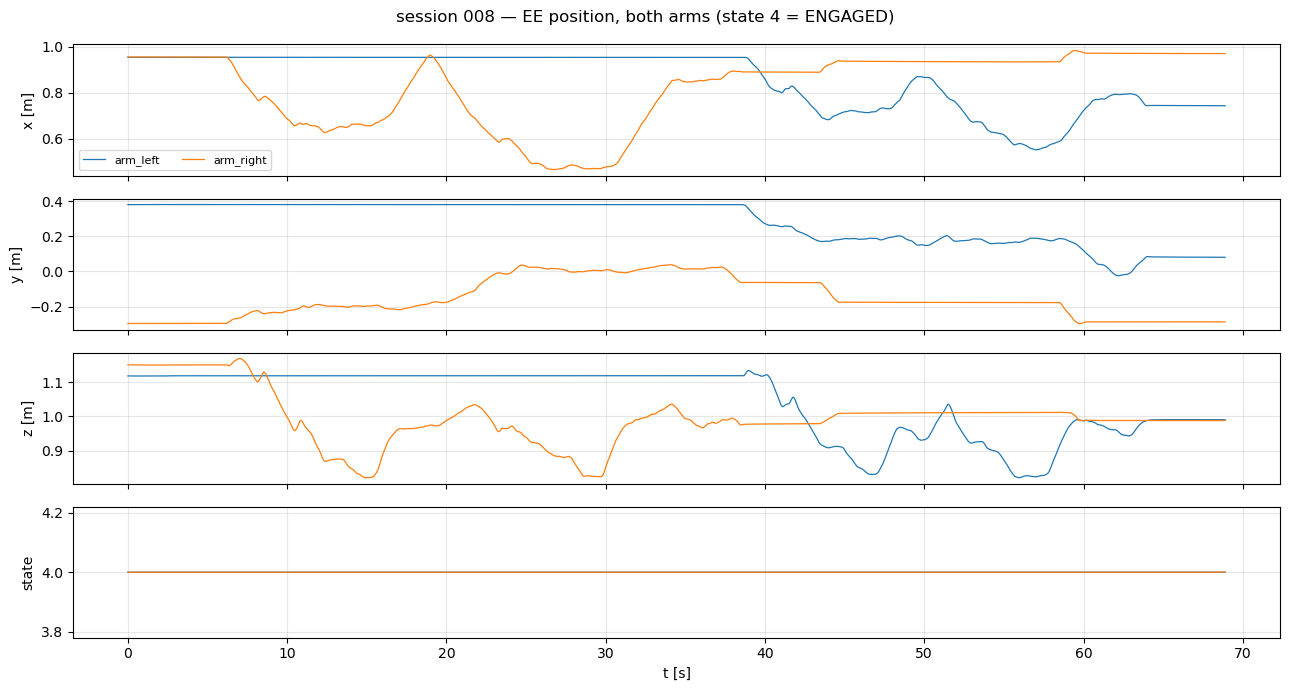

In [163]:
# Both arms, for orientation in the session before zooming into one.
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(13, 7))
for name, d in arms.items():
    for i, lbl in enumerate("xyz"):
        axs[i].plot(d["t"], d["pos"][:, i], lw=0.9, label=name)
        axs[i].set_ylabel(f"{lbl} [m]")
    axs[3].step(d["t"], d["state"], where="post", lw=0.9, label=name)
axs[3].set_ylabel("state")
grid(axs)
plt.suptitle(f"session {SESSION} — EE position, both arms (state 4 = ENGAGED)")
plt.tight_layout()

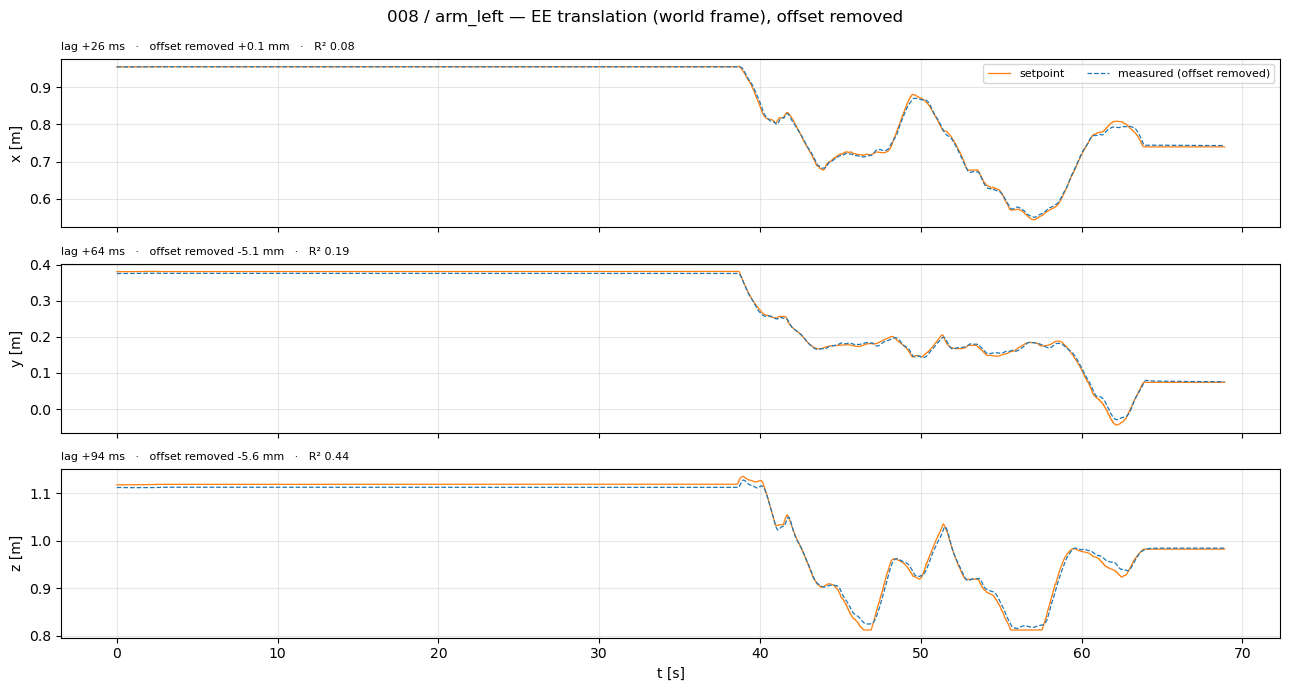

In [164]:
A = arms[ARM]
LAG = lag_offset(A["t"], A["set_pos"], A["pos"])

# Measured carries a constant offset AS WELL AS a lag. On a low-amplitude axis
# the offset alone moves every crossing point enough that the arm appears to
# lead its own setpoint -- it does not, and cannot. Remove the offset here so
# the overlay shows lag only; what was removed is in each subplot title.
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(13, 7))
for i, lbl in enumerate("xyz"):
    axs[i].plot(A["t"], A["set_pos"][:, i], lw=0.9, color="tab:orange", label="setpoint")
    axs[i].plot(A["t"], A["pos"][:, i] + LAG["offset_m"][i], lw=0.9, ls="--",
                color="tab:blue", label="measured (offset removed)")
    axs[i].set_ylabel(f"{lbl} [m]")
    axs[i].set_title(f"lag {LAG['lag_ms'][i]:+.0f} ms   ·   offset removed "
                     f"{LAG['offset_m'][i] * 1e3:+.1f} mm   ·   R² {LAG['r2'][i]:.2f}",
                     fontsize=8, loc="left")
grid(axs, ncol=2)
plt.suptitle(f"{SESSION} / {ARM} — EE translation (world frame), offset removed")
plt.tight_layout()


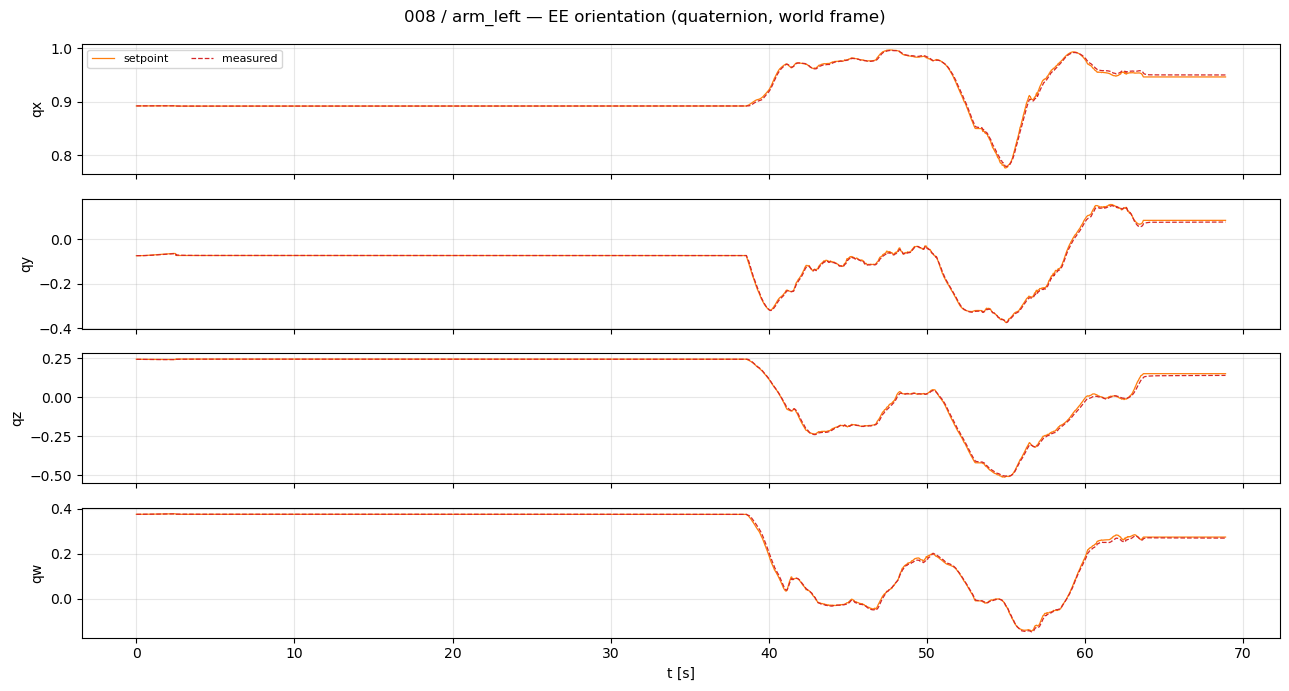

In [165]:
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(13, 7))
qs, qm = A["set_rot"].as_quat(), A["rot"].as_quat()
for i, lbl in enumerate(["x", "y", "z", "w"]):
    axs[i].plot(A["t"], qs[:, i], lw=0.9, color="tab:orange", label="setpoint")
    axs[i].plot(A["t"], qm[:, i], lw=0.9, ls="--", color="tab:red", label="measured")
    axs[i].set_ylabel(f"q{lbl}")
grid(axs)
plt.suptitle(f"{SESSION} / {ARM} — EE orientation (quaternion, world frame)")
plt.tight_layout()

67567


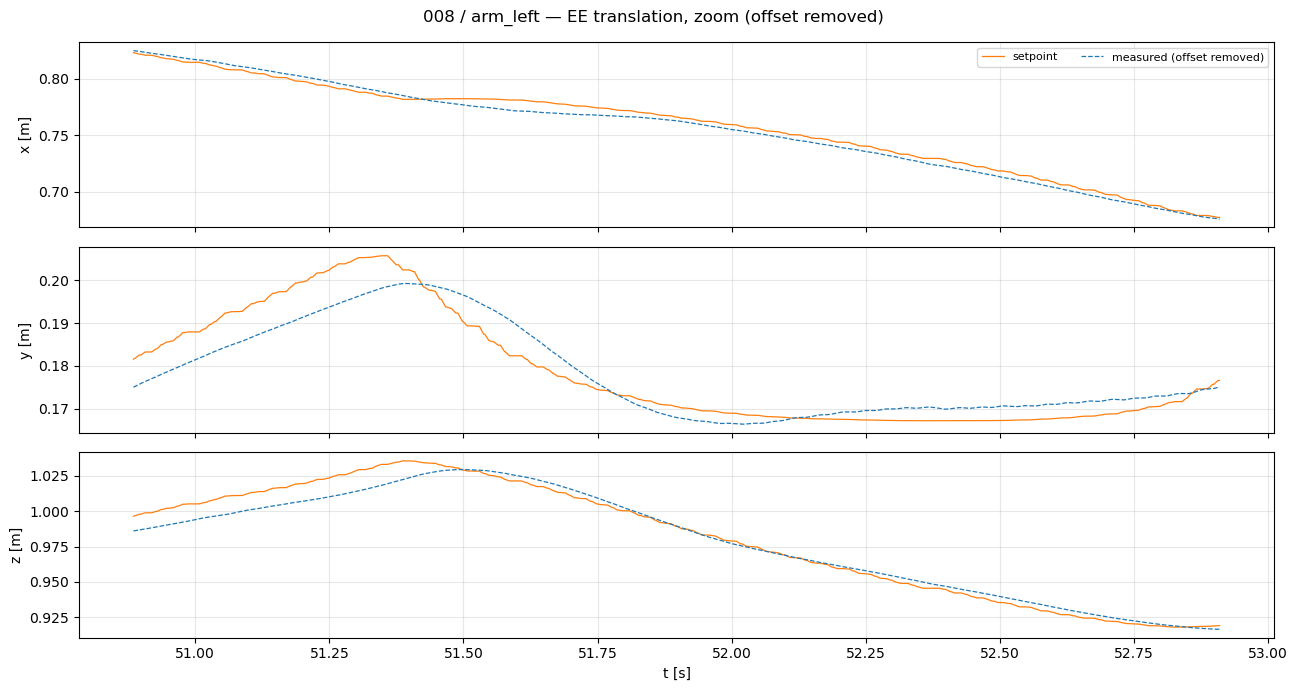

In [166]:
print(len(A["t"]))
start, stop = 50000, 52000
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(13, 7))
for i, lbl in enumerate("xyz"):
    sl = slice(start, stop)
    axs[i].plot(A["t"][sl], A["set_pos"][sl, i], lw=0.9, color="tab:orange", label="setpoint")
    axs[i].plot(A["t"][sl], A["pos"][sl, i] + LAG["offset_m"][i], lw=0.9, ls="--",
                color="tab:blue", label="measured (offset removed)")
    axs[i].set_ylabel(f"{lbl} [m]")
grid(axs, ncol=2)
plt.suptitle(f"{SESSION} / {ARM} — EE translation, zoom (offset removed)")
plt.tight_layout()


## How much lag, and is it really lag

Two independent estimates per axis. They use different properties of the signal, so
agreeing is evidence and disagreeing is a finding.

- **Left column** — error against commanded velocity. The fitted *slope* is the lag
  (error that grows with speed); the *intercept* is a constant offset (error that does
  not). This is the plot that separates the two.
- **Right column** — normalised cross-correlation against lag. The peak is the lag by
  waveform alignment. Positive means the arm lags; a peak left of zero would mean it
  leads, which would indicate a bug in the comparison rather than in the robot.


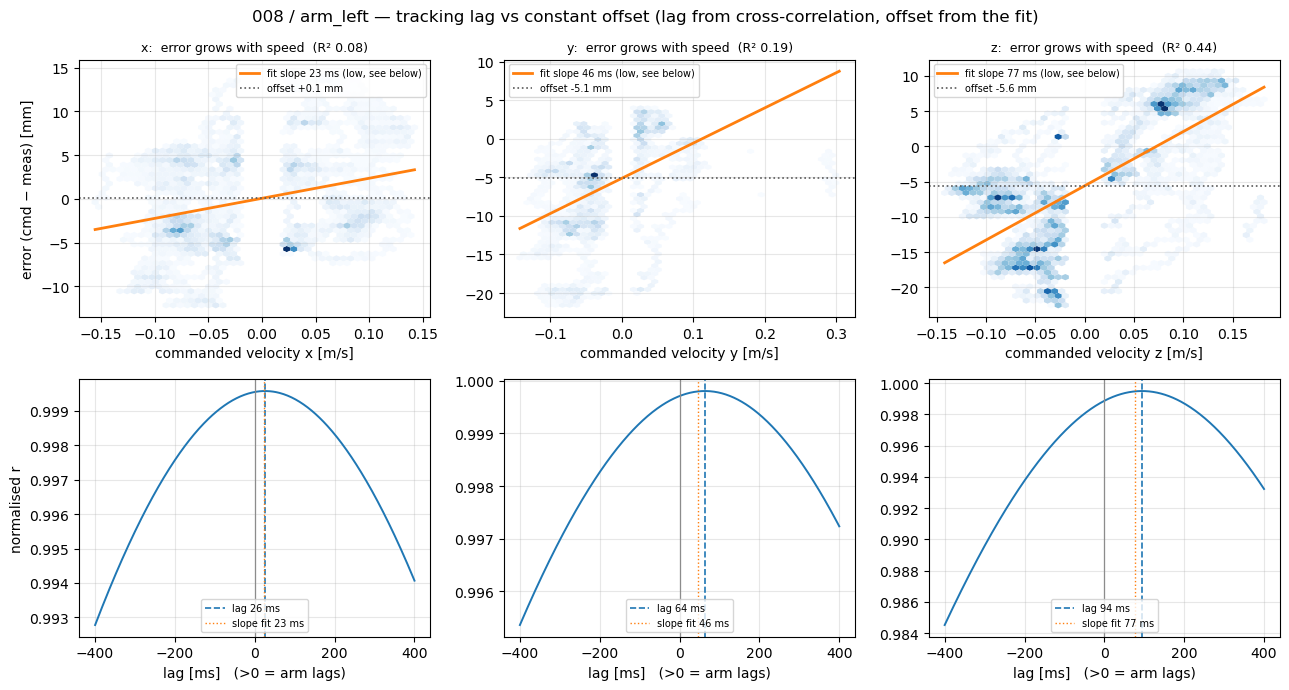

In [167]:
v_cmd = _smooth(np.gradient(A["set_pos"], A["t"], axis=0))
err_mm = _smooth(A["set_pos"] - A["pos"]) * 1e3
lags, R = LAG["_lags"], LAG["_R"]

fig, axs = plt.subplots(2, 3, figsize=(13, 7))
for i, lbl in enumerate("xyz"):
    peak, slope, b_mm = LAG["lag_ms"][i], LAG["slope_lag_ms"][i], LAG["offset_m"][i] * 1e3

    ax = axs[0, i]
    m = np.abs(v_cmd[:, i]) > 0.02
    ax.hexbin(v_cmd[m, i], err_mm[m, i], gridsize=45, cmap="Blues", mincnt=1, linewidths=0)
    xs = np.linspace(v_cmd[m, i].min(), v_cmd[m, i].max(), 2)
    ax.plot(xs, slope * xs + b_mm, color="tab:orange", lw=2,
            label=f"fit slope {slope:.0f} ms (low, see below)")
    ax.axhline(b_mm, color="0.35", lw=1.2, ls=":", label=f"offset {b_mm:+.1f} mm")
    ax.set_xlabel(f"commanded velocity {lbl} [m/s]")
    ax.set_ylabel("error (cmd − meas) [mm]" if i == 0 else "")
    ax.set_title(f"{lbl}:  error grows with speed  (R² {LAG['r2'][i]:.2f})", fontsize=9)
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.3)

    ax = axs[1, i]
    ax.plot(lags, R[:, i], lw=1.4, color="tab:blue")
    ax.axvline(peak, color="tab:blue", lw=1.2, ls="--", label=f"lag {peak:.0f} ms")
    ax.axvline(slope, color="tab:orange", lw=1, ls=":", label=f"slope fit {slope:.0f} ms")
    ax.axvline(0, color="0.55", lw=0.9)
    ax.set_xlabel("lag [ms]   (>0 = arm lags)")
    ax.set_ylabel("normalised r" if i == 0 else "")
    ax.legend(fontsize=7, loc="lower center")
    ax.grid(True, alpha=0.3)

plt.suptitle(f"{SESSION} / {ARM} — tracking lag vs constant offset "
             f"(lag from cross-correlation, offset from the fit)")
plt.tight_layout()


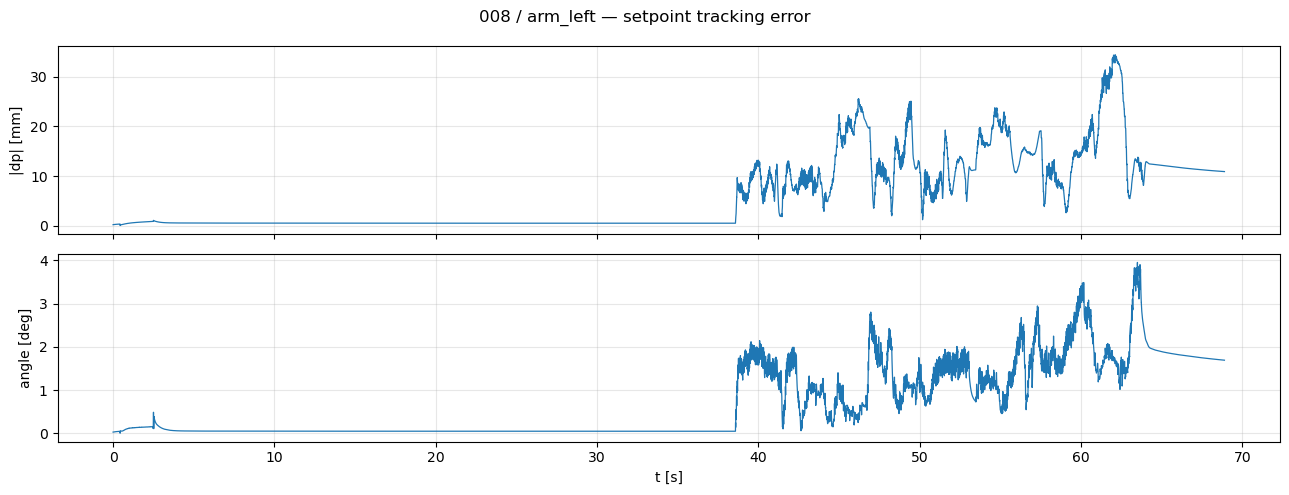

In [168]:
# How far the arm is from the target it is currently being driven toward.
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(13, 5))
axs[0].plot(A["t"], np.linalg.norm(A["set_pos"] - A["pos"], axis=1) * 1e3, lw=0.9)
axs[0].set_ylabel("|dp| [mm]")
axs[1].plot(A["t"], np.degrees((A["set_rot"] * A["rot"].inv()).magnitude()), lw=0.9)
axs[1].set_ylabel("angle [deg]")
grid(axs)
plt.suptitle(f"{SESSION} / {ARM} — setpoint tracking error")
plt.tight_layout()

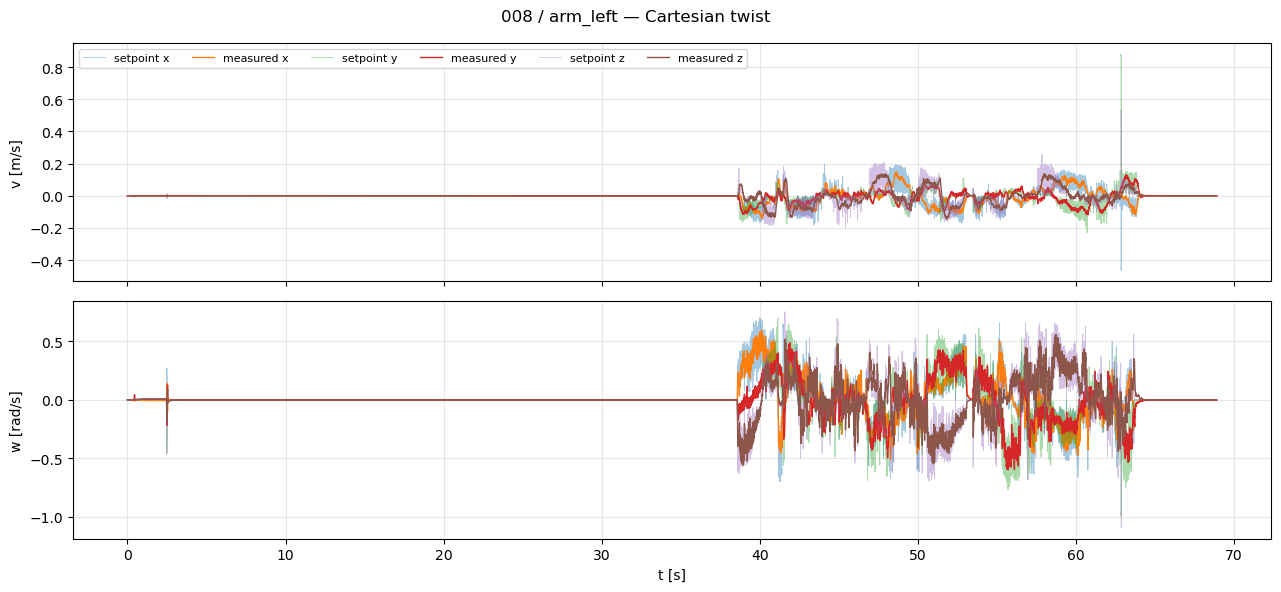

In [169]:
# Twist, differentiated from the logged poses rather than J*dq. A sawtooth on the
# setpoint traces is the command rate showing through the motion generator, not noise.
v_m, v_s = deriv(A["t"], A["pos"]), deriv(A["t"], A["set_pos"])
w_m, w_s = ang_vel(A["t"], A["rot"]), ang_vel(A["t"], A["set_rot"])

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(13, 6))
for i, lbl in enumerate("xyz"):
    axs[0].plot(A["t"], v_s[:, i], lw=0.6, alpha=0.4, label=f"setpoint {lbl}")
    axs[0].plot(A["t"], v_m[:, i], lw=1.0, label=f"measured {lbl}")
    axs[1].plot(A["t"], w_s[:, i], lw=0.6, alpha=0.4, label=f"setpoint {lbl}")
    axs[1].plot(A["t"], w_m[:, i], lw=1.0, label=f"measured {lbl}")
axs[0].set_ylabel("v [m/s]")
axs[1].set_ylabel("w [rad/s]")
grid(axs, ncol=6)
plt.suptitle(f"{SESSION} / {ARM} — Cartesian twist")
plt.tight_layout()

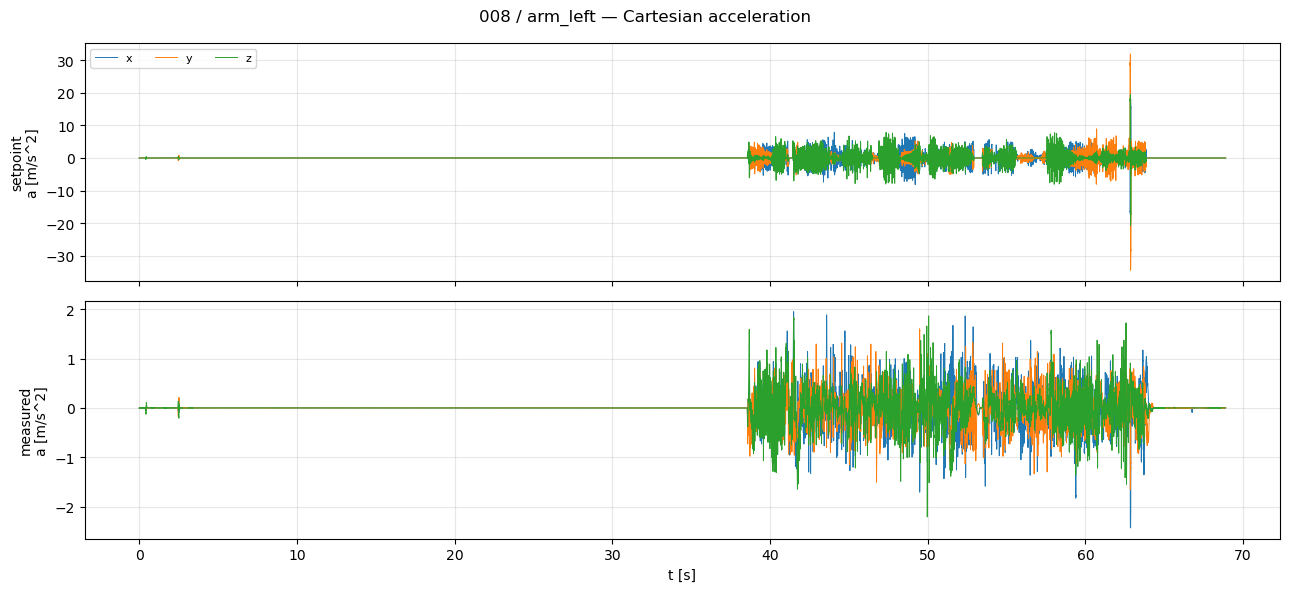

In [170]:
# Acceleration is double-differentiated: read it for shape and timing, not magnitude.
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(13, 6))
for i, lbl in enumerate("xyz"):
    axs[0].plot(A["t"], deriv(A["t"], v_s)[:, i], lw=0.7, label=lbl)
    axs[1].plot(A["t"], deriv(A["t"], v_m)[:, i], lw=0.7, label=lbl)
axs[0].set_ylabel("setpoint\na [m/s^2]")
axs[1].set_ylabel("measured\na [m/s^2]")
grid(axs, ncol=3)
plt.suptitle(f"{SESSION} / {ARM} — Cartesian acceleration")
plt.tight_layout()

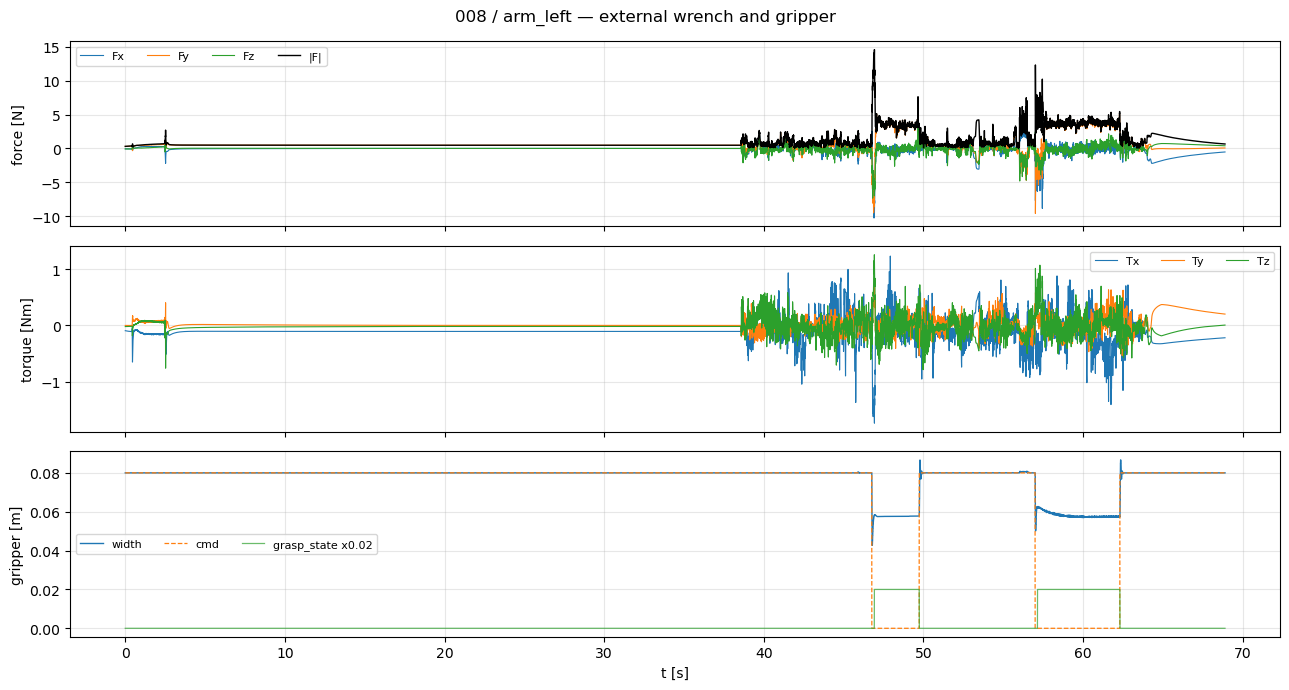

In [171]:
# Contact. grasp_state is arm_control's sensor-derived confirmation
# (0 open / 1 held / 2 lost), not a repeat of the gripper command.
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(13, 7))
for i, lbl in enumerate("xyz"):
    axs[0].plot(A["t"], A["F_ext"][:, i], lw=0.8, label=f"F{lbl}")
    axs[1].plot(A["t"], A["F_ext"][:, 3 + i], lw=0.8, label=f"T{lbl}")
axs[0].plot(A["t"], np.linalg.norm(A["F_ext"][:, :3], axis=1), lw=1.0, color="k", label="|F|")
axs[0].set_ylabel("force [N]")
axs[1].set_ylabel("torque [Nm]")
axs[2].plot(A["t"], A["gripper_width"], lw=1.0, label="width")
axs[2].plot(A["t"], A["gripper_cmd"], lw=0.9, ls="--", label="cmd")
axs[2].plot(A["t"], A["grasp_state"] * 0.02, lw=0.9, alpha=0.7, label="grasp_state x0.02")
axs[2].set_ylabel("gripper [m]")
for ax in axs:
    ax.legend(ncol=4, fontsize=8)
grid(axs)
plt.suptitle(f"{SESSION} / {ARM} — external wrench and gripper")
plt.tight_layout()

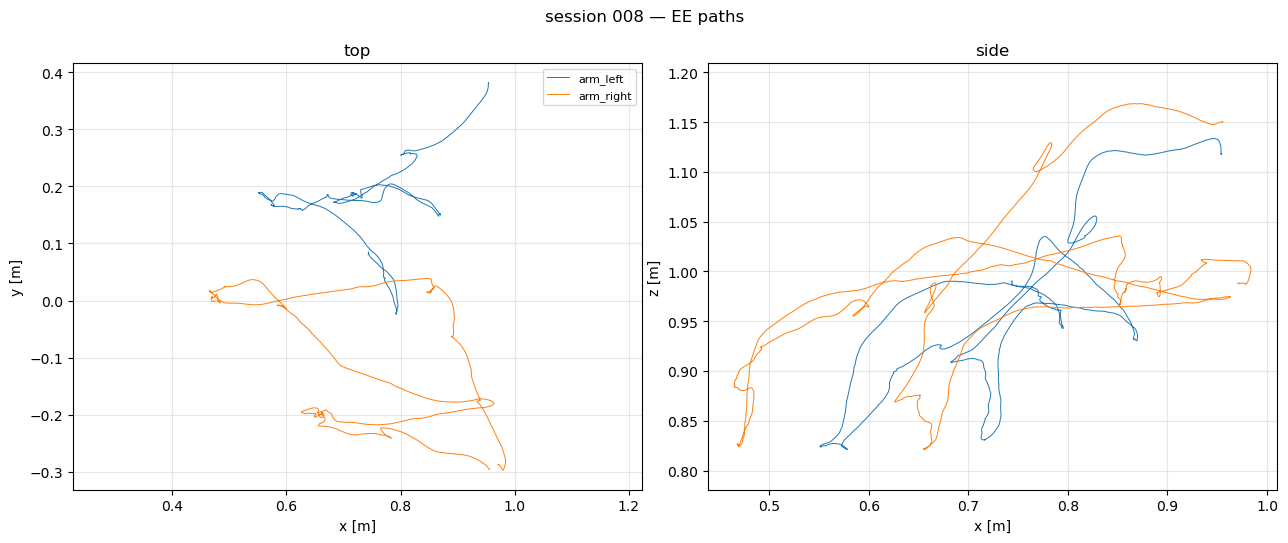

In [172]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
for name, d in arms.items():
    axs[0].plot(d["pos"][:, 0], d["pos"][:, 1], lw=0.7, label=name)
    axs[1].plot(d["pos"][:, 0], d["pos"][:, 2], lw=0.7, label=name)
axs[0].set_xlabel("x [m]"); axs[0].set_ylabel("y [m]"); axs[0].set_title("top")
axs[1].set_xlabel("x [m]"); axs[1].set_ylabel("z [m]"); axs[1].set_title("side")
for ax in axs:
    ax.set_aspect("equal", "datalim")
    ax.grid(True, alpha=0.3)
axs[0].legend(fontsize=8)
plt.suptitle(f"session {SESSION} — EE paths")
plt.tight_layout()

## Joints

Secondary: for explaining a Cartesian behaviour that already looks wrong. `tau_cmd` is
post rate-limit and post-saturation — exactly the vector handed to the robot — so a
flat top on it is the limiter, not the controller giving up.

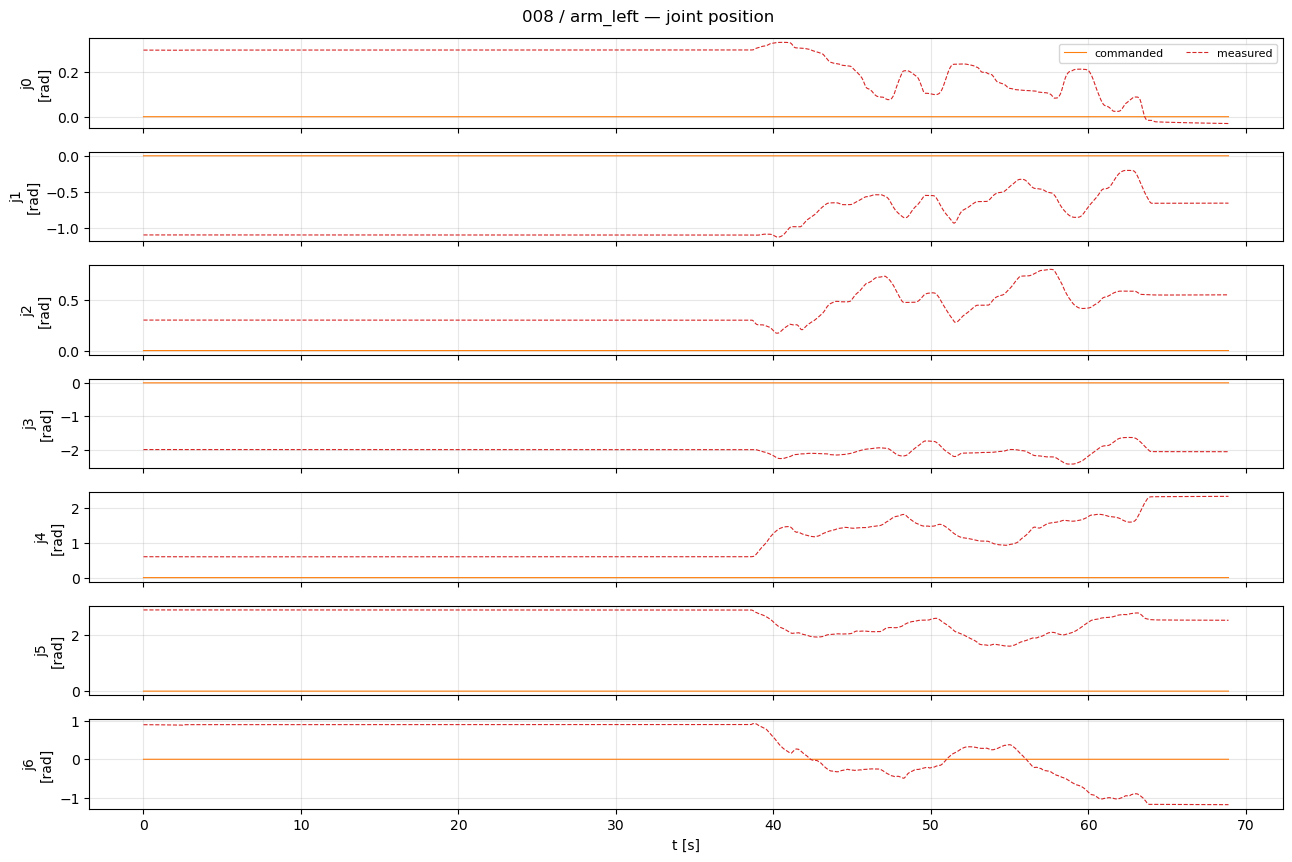

In [173]:
def plot_joints(key, cmd_key=None, unit="", title=""):
    n = A[key].shape[1]
    fig, axs = plt.subplots(n, 1, sharex=True, figsize=(13, 1.25 * n))
    for j in range(n):
        if cmd_key:
            axs[j].plot(A["t"], A[cmd_key][:, j], lw=0.8, color="tab:orange", label="commanded")
        axs[j].plot(A["t"], A[key][:, j], lw=0.8, ls="--", color="tab:red", label="measured")
        axs[j].set_ylabel(f"j{j}\n{unit}")
    grid(axs, ncol=2)
    plt.suptitle(f"{SESSION} / {ARM} — {title or key}")
    plt.tight_layout()


plot_joints("q", "q_cmd", "[rad]", "joint position")

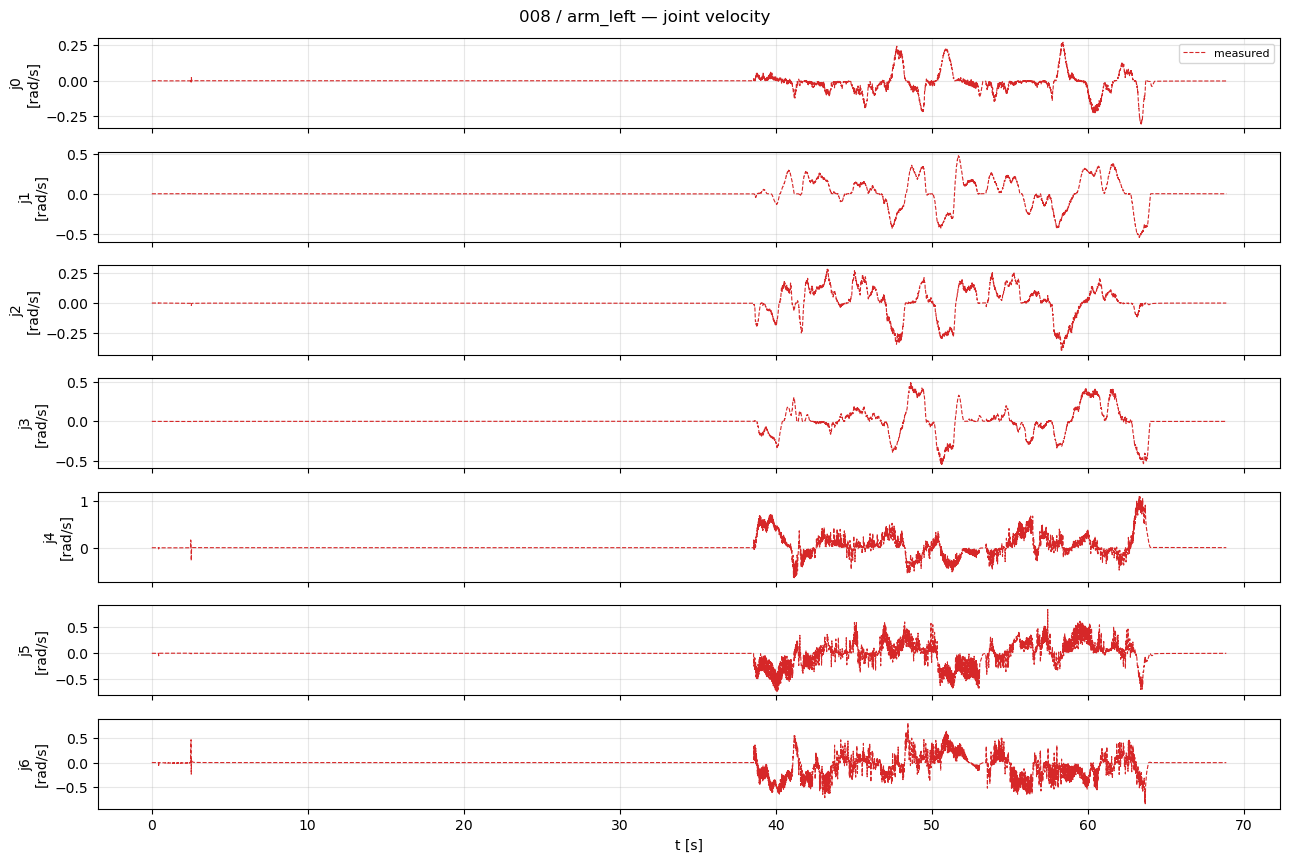

In [174]:
plot_joints("dq", unit="[rad/s]", title="joint velocity")

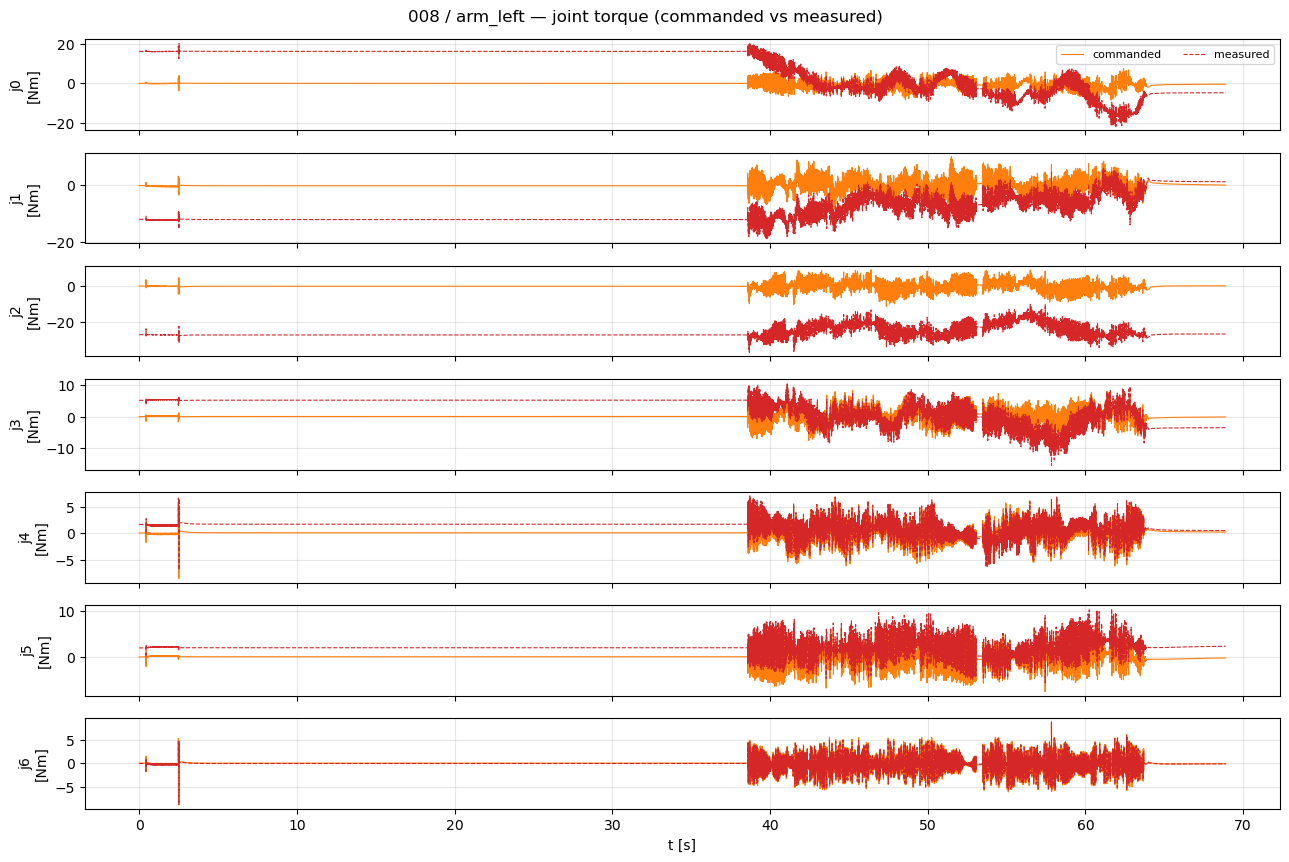

In [175]:
plot_joints("tau_J", "tau_cmd", "[Nm]", "joint torque (commanded vs measured)")

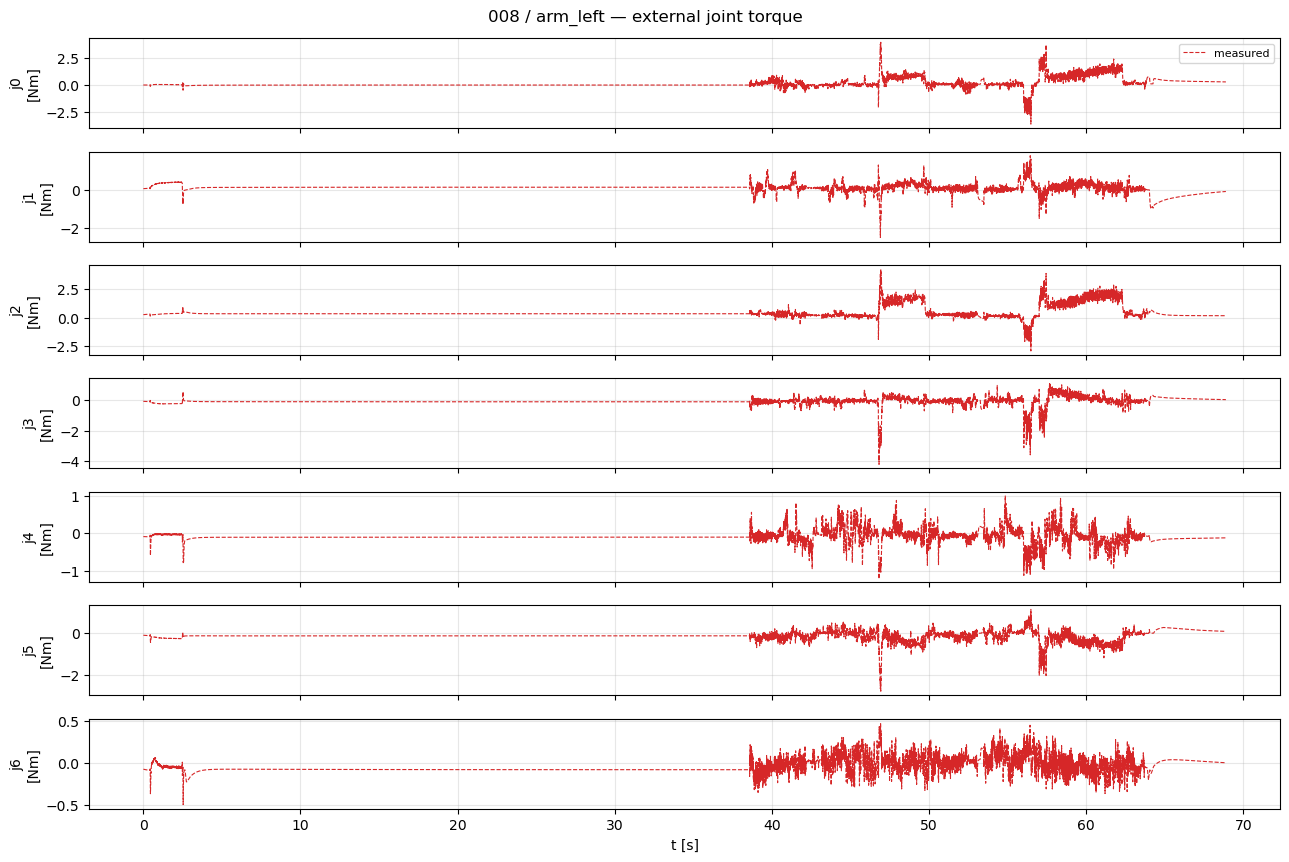

In [176]:
plot_joints("tau_ext", unit="[Nm]", title="external joint torque")

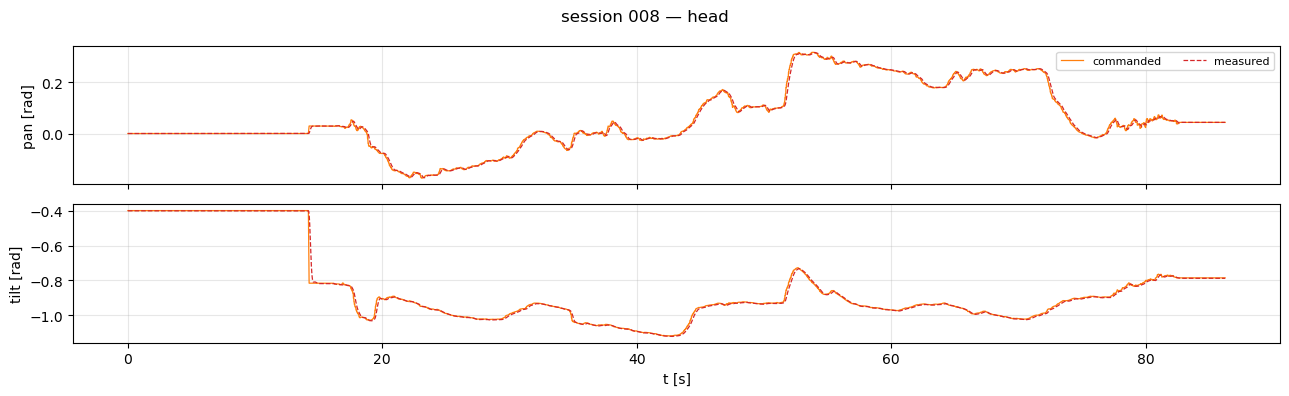

In [177]:
if head is not None:
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(13, 4))
    for j, lbl in enumerate(("pan", "tilt")):
        axs[j].plot(head["t"], head["q_cmd"][:, j], lw=0.9, color="tab:orange", label="commanded")
        axs[j].plot(head["t"], head["q"][:, j], lw=0.9, ls="--", color="tab:red", label="measured")
        axs[j].set_ylabel(f"{lbl} [rad]")
    grid(axs, ncol=2)
    plt.suptitle(f"session {SESSION} — head")
    plt.tight_layout()
else:
    print("no head.csv in this session")